In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))


# ESS 배터리 수명 예측 · EDA

MIT–Stanford 데이터의 배치별 수명, 열화 곡선, ΔQ(V), 충전 정책을 분석한다. 수명과 전체 열화 곡선은 설명용이며 모델 입력은 초기 100사이클로 제한한다. Batch 2·3 분석은 외부 배치 진단이며 독립적인 미관측 Test를 의미하지 않는다.

In [2]:
from src.eda import run_eda
OUT=ROOT/'results/eda'
table=run_eda(ROOT,OUT)
display(table.groupby('batch').size().rename('cells').to_frame())

,cells
batch,
1,46
2,39
3,44


## Cycle Life 분포

550사이클 미만을 단수명으로 정의하여 분류 가능성도 점검한다. Batch 1의 단수명 셀은 1개라 회귀를 선택한다.

,batch,n,mean,median,minimum,maximum,below_500_pct,short_lt550_n,long_ge550_n,outside_batch1_pct
0,1,46,844.717,858.5,534.0,1227.0,0.000,1,45,0.000
1,2,39,565.744,472.0,392.0,1186.0,71.795,30,9,76.923
2,3,44,1059.659,1005.5,541.0,1935.0,0.000,1,43,20.455


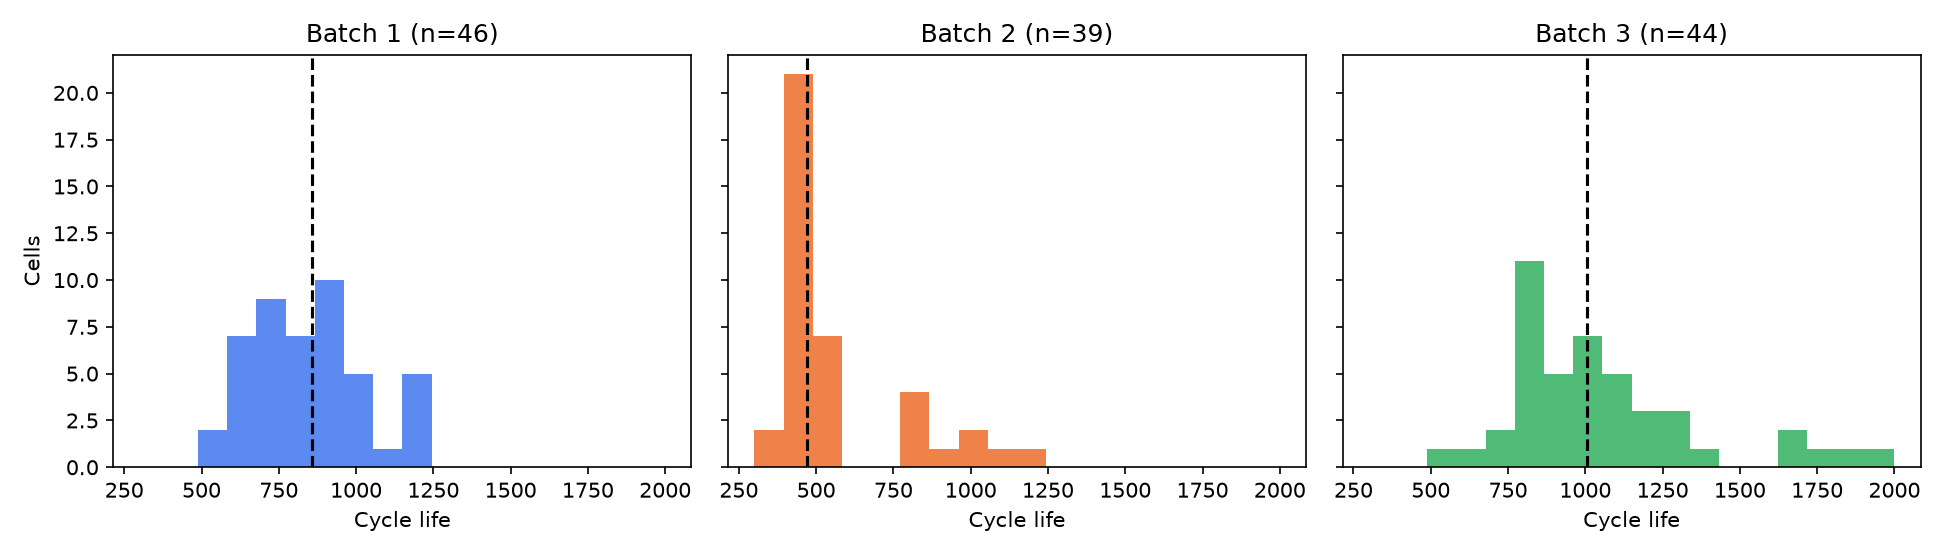

In [3]:
display(pd.read_csv(OUT/'lifetime_summary.csv').round(3))
display(Image(filename=str(OUT/'lifetime_distribution.png')))

Batch 2 중앙값은 472사이클이며 76.9%가 Batch 1 수명 범위 밖이다. 내부 검증만으로 외부 성능을 판단하기 어렵다.

## 열화 곡선 분석

상단은 전체 수명, 하단은 초기 100사이클의 상대 용량이다. 곡선 색은 수명 순서를 나타낸다. 전체 수명 데이터는 EDA 함수에서만 읽는다.

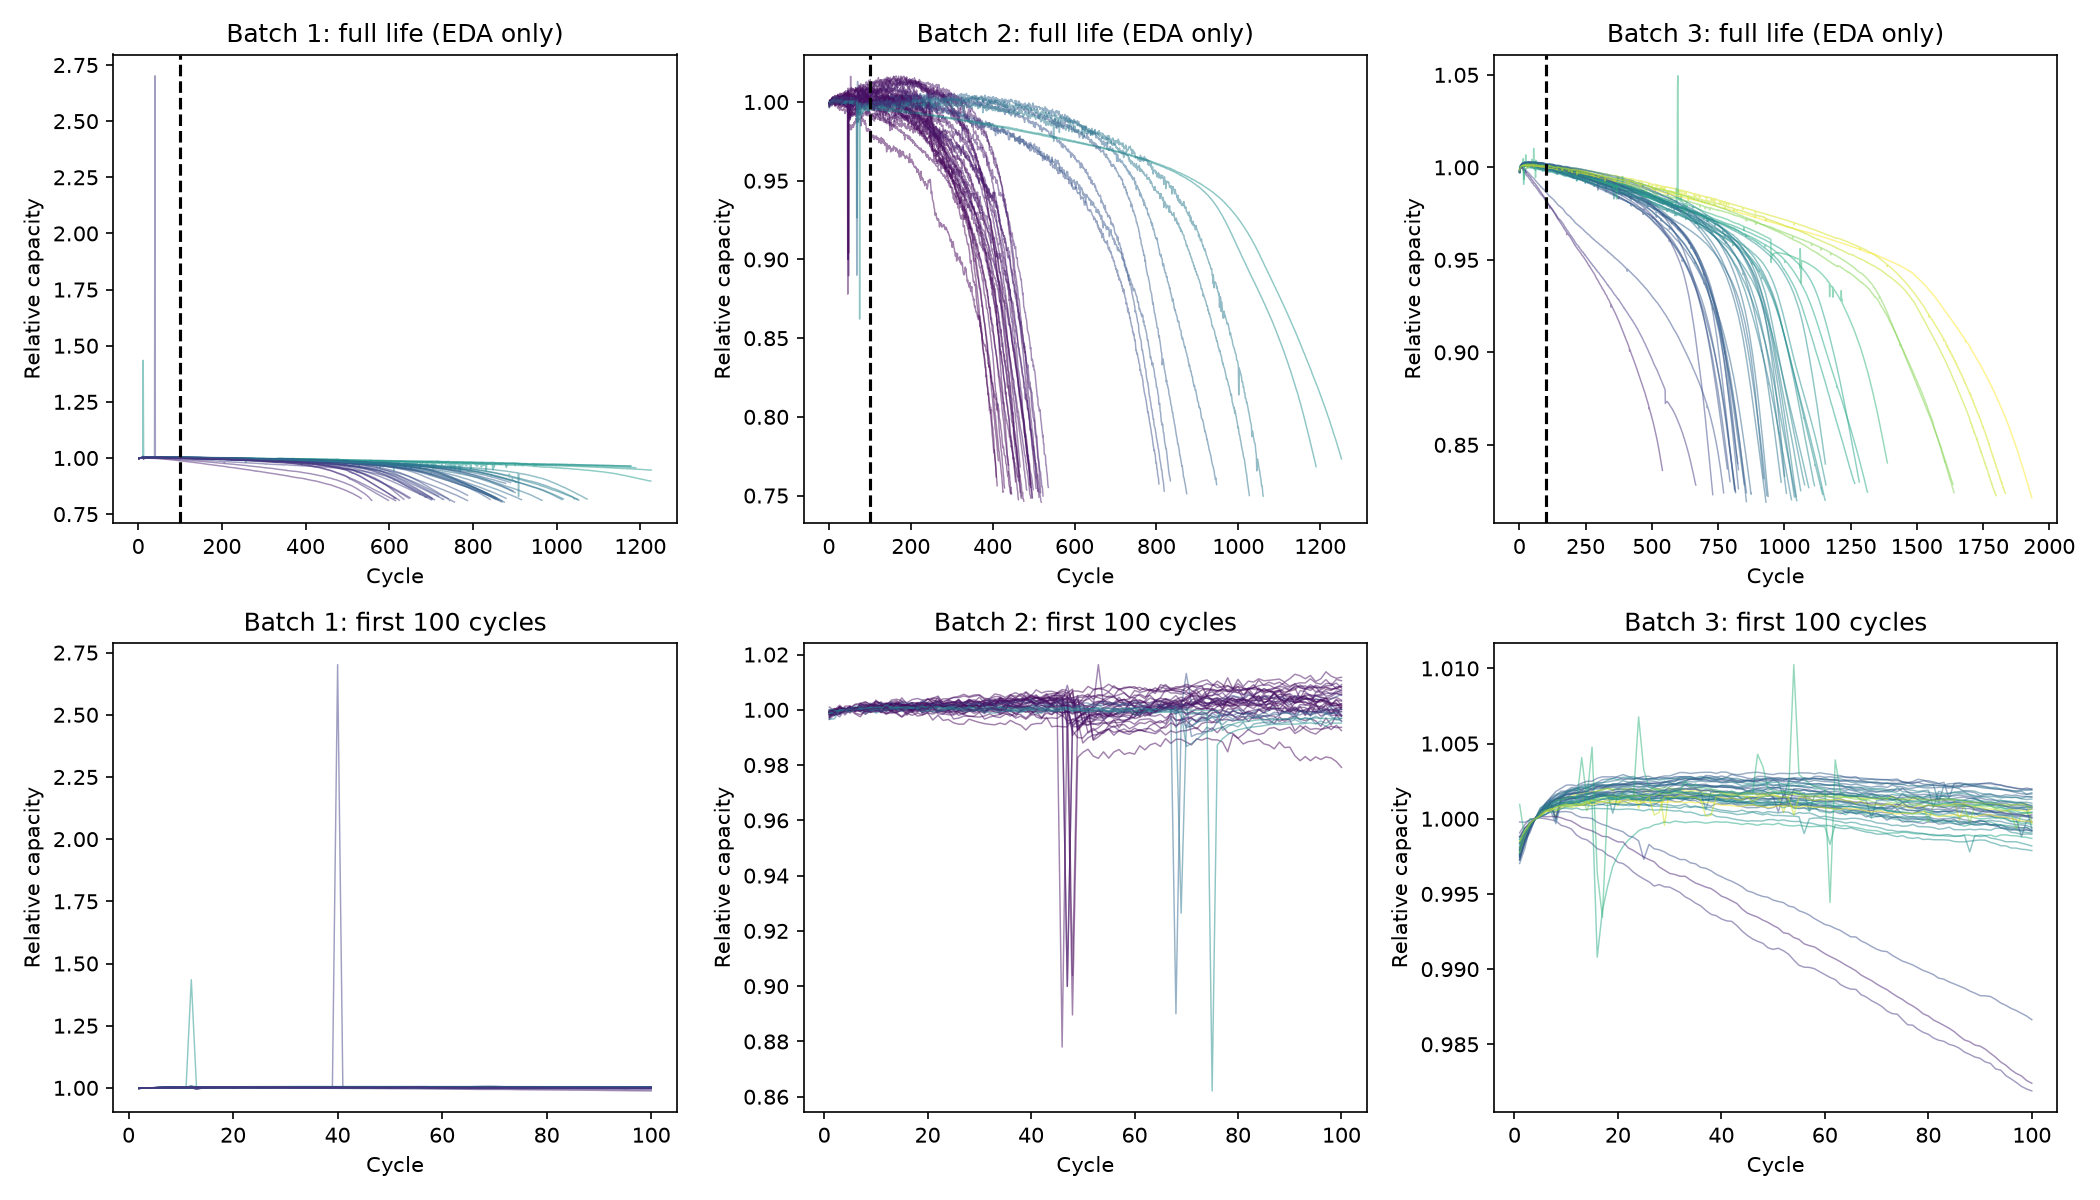

,detected_n,median_knee,median_life_ratio
batch,,,
1,45,606.354,0.745
2,39,360.573,0.782
3,44,818.669,0.793


In [4]:
display(Image(filename=str(OUT/'capacity_degradation.png')))
knee=pd.read_csv(OUT/'knee_diagnostics.csv')
display(knee.groupby('batch').agg(detected_n=('knee_cycle','count'),median_knee=('knee_cycle','median'),median_life_ratio=('knee_life_ratio','median')).round(3))

초기 총용량 차이는 작고 후반에 용량 저하가 가속된다. knee는 이동 중앙값으로 평활화한 곡선의 연속 두 직선 회귀로 탐색한다. 단일 직선 대비 SSE가 50% 이상 감소하고 후기 기울기가 더 작을 때 후보로 표시한다. 탐색 구간·평활화에 의존하는 설명용 추정이며 물리적 knee의 확정값이나 모델 피처로 사용하지 않는다.

## ΔQ(V) 곡선 분석

Cycle 100−Cycle 10을 2.0–3.5V 공통 300점 격자에서 계산한다. 각 배치 수명 하위·상위 1/3의 중앙값과 25–75% 범위를 비교한다.

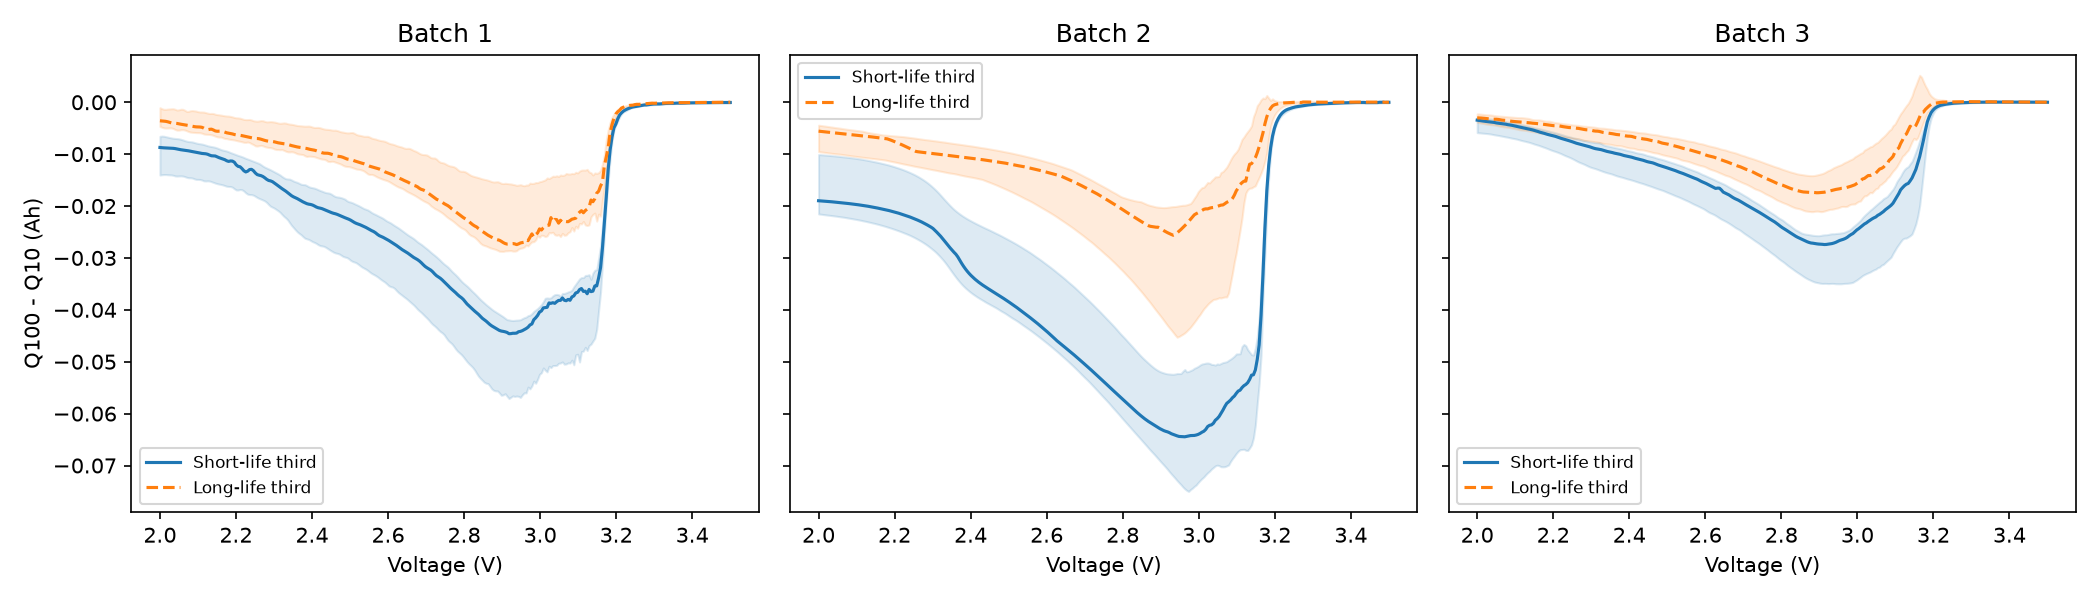

,batch,feature,n,spearman,pearson,pearson_log_target
0,All,log10_dq_var,129,-0.892,-0.850,-0.886
18,1,log10_dq_var,46,-0.871,-0.886,-0.868
36,2,log10_dq_var,39,-0.709,-0.902,-0.918
54,3,log10_dq_var,44,-0.797,-0.701,-0.761


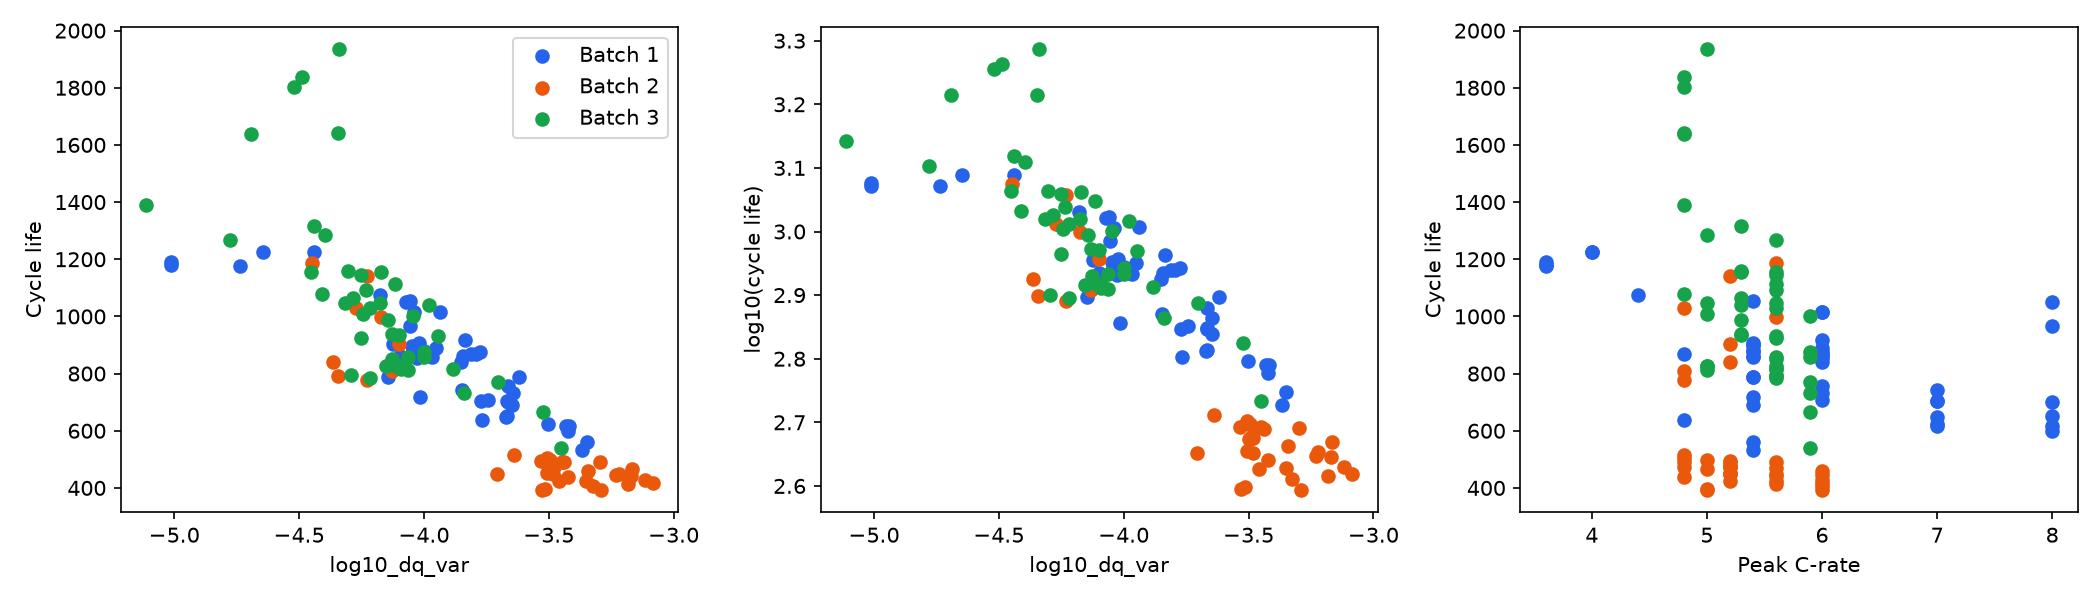

In [5]:
display(Image(filename=str(OUT/'delta_q_curves.png')))
corr=pd.read_csv(OUT/'correlations.csv')
display(corr[corr.feature.eq('log10_dq_var')].round(3))
display(Image(filename=str(OUT/'feature_lifetime.png')))

log10_dq_var의 수명 상관은 모든 배치에서 음수다. Batch 2의 높은 상관은 Batch 1에서 학습한 절편·기울기가 동일함을 보장하지 않는다. 원 수명과 로그 수명은 모델링에서 별도로 비교한다.

## 충전 속도와 수명의 관계

In [6]:
policy=pd.read_csv(OUT/'policy_lifetime.csv')
display(policy.round(2))
display(corr[corr.feature.isin(['peak_c_rate','switch_soc','chargetime_median_100'])].round(3))

,batch,policy,count,mean,median,min,max
0,1,3.6C(80%)-3.6C,3,1182.00,1179.0,1177.0,1190.0
1,1,4.4C(80%)-4.4C,1,1074.00,1074.0,1074.0,1074.0
2,1,4.8C(80%)-4.8C,2,753.00,753.0,636.0,870.0
3,1,4C(80%)-4C,2,1226.50,1226.5,1226.0,1227.0
4,1,5.4C(40%)-3.6C,2,966.50,966.5,879.0,1054.0
5,1,5.4C(50%)-3.6C,2,899.50,899.5,897.0,902.0
6,1,5.4C(50%)-3C,2,847.00,847.0,788.0,906.0
7,1,5.4C(60%)-3.6C,2,859.50,859.5,857.0,862.0
8,1,5.4C(60%)-3C,2,799.50,799.5,719.0,880.0
9,1,5.4C(70%)-3C,2,739.50,739.5,691.0,788.0


,batch,feature,n,spearman,pearson,pearson_log_target
1,All,peak_c_rate,129,-0.233,-0.260,-0.200
2,All,switch_soc,129,0.160,0.222,0.175
14,All,chargetime_median_100,129,-0.027,0.315,0.322
19,1,peak_c_rate,46,-0.483,-0.580,-0.552
20,1,switch_soc,46,0.185,0.235,0.183
32,1,chargetime_median_100,46,0.641,0.744,0.731
37,2,peak_c_rate,39,-0.359,-0.161,-0.204
38,2,switch_soc,39,0.288,0.116,0.164
50,2,chargetime_median_100,39,-0.811,-0.919,-0.936
55,3,peak_c_rate,44,-0.607,-0.657,-0.660


최대 C-rate와 수명은 배치 내부에서도 음의 상관을 보인다. 같은 충전 정책에서도 수명 차이가 나타나므로 정책만으로 예측하지 않고 ΔQ와 결합한다.

## 추가 확인 · 입력 분포와 결측

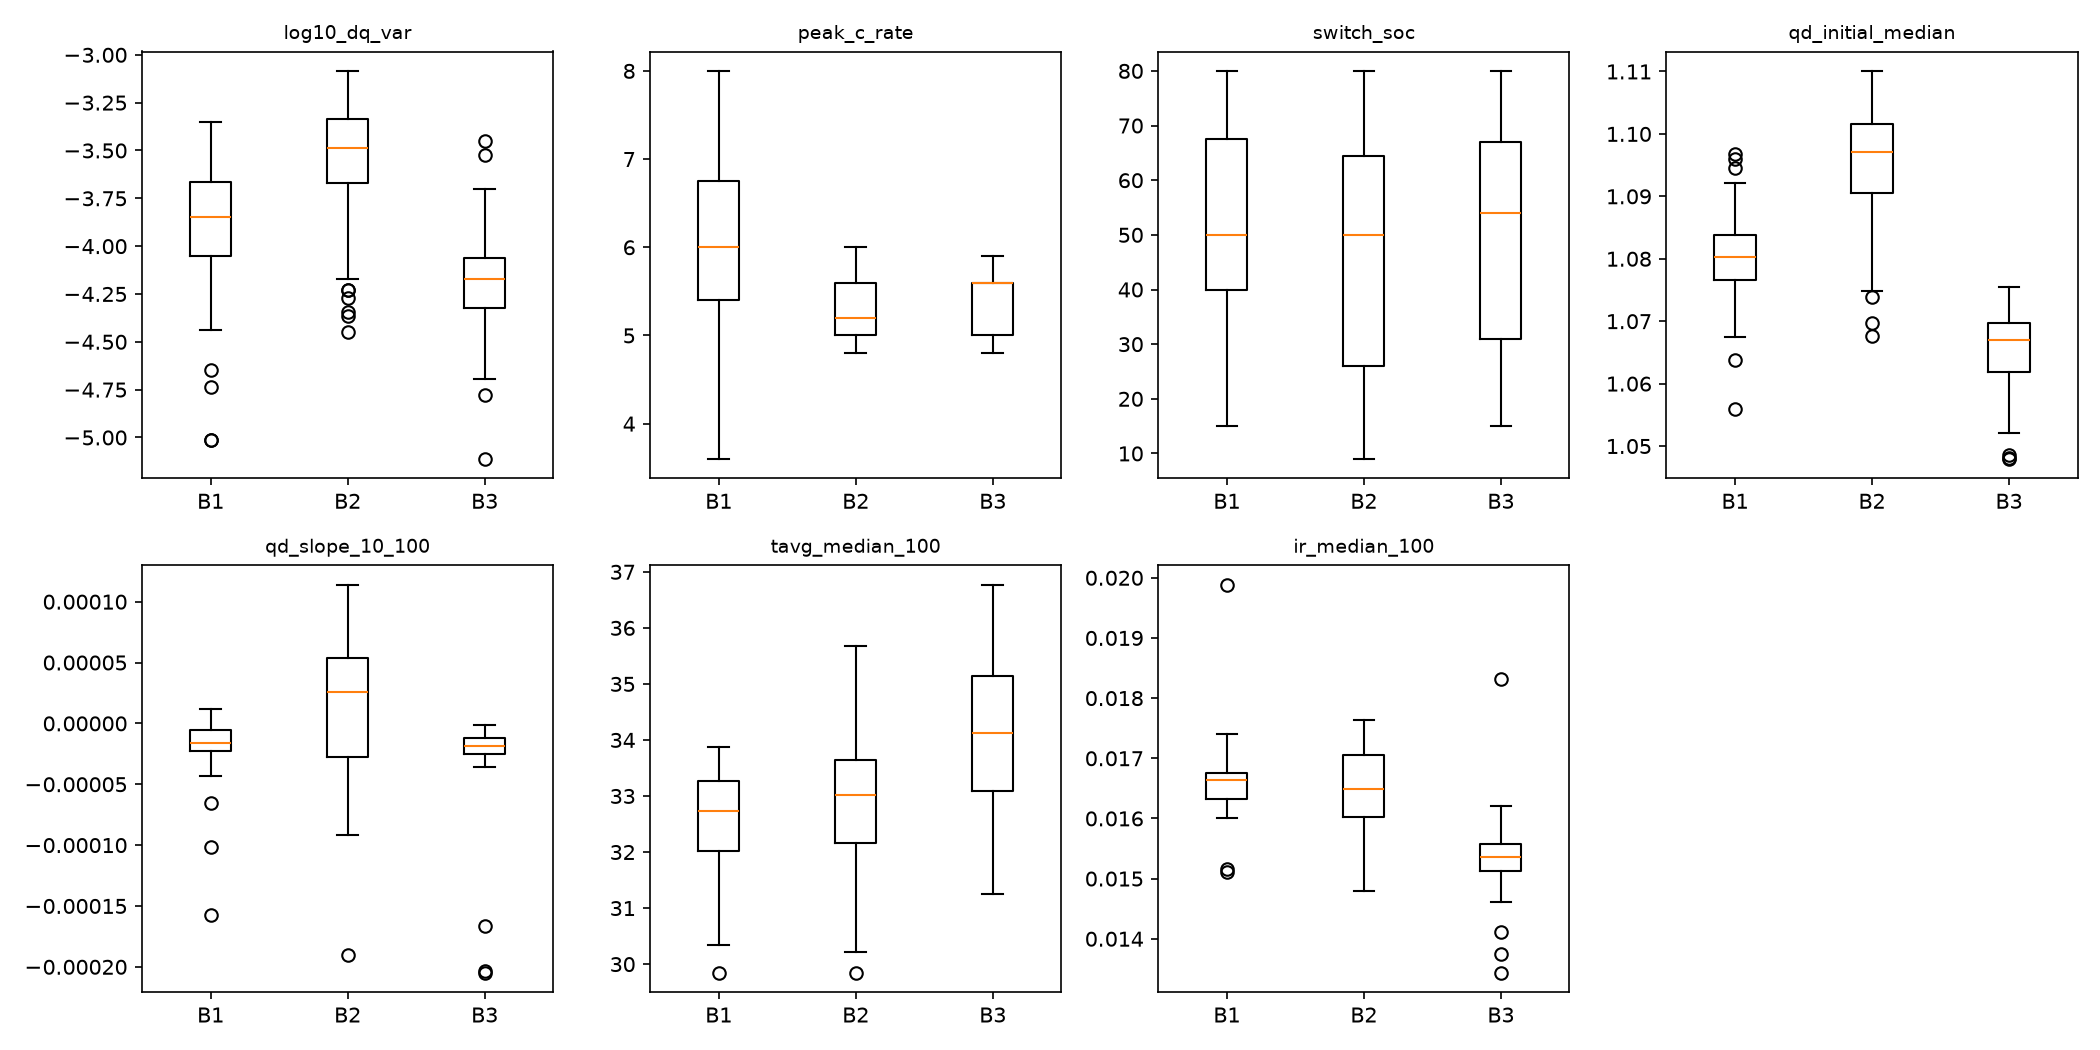

log10_dq_var       qd_initial_median       qd_slope_10_100        \
            median count            median count          median count   
batch                                                                    
1        -3.849456    46          1.080308    46       -0.000016    46   
2        -3.485534    39          1.097156    39        0.000025    39   
3        -4.173546    44          1.066930    44       -0.000019    44   

      ir_median_100        
             median count  
batch                      
1          0.016642    46  
2          0.016496    33  
3          0.015367    44

In [7]:
display(Image(filename=str(OUT/'feature_distributions.png')))
display(table.groupby('batch')[['log10_dq_var','qd_initial_median','qd_slope_10_100','ir_median_100']].agg(['median','count']).round(6))

Batch 2 IR은 6셀에서 결측이다. 용량·온도·IR은 보조 피처로 단계적으로 평가한다. 전체 배치 통계로 대치하거나 표준화하지 않는다. 모델 선택은 Batch 1 Train CV로 수행한다.

참고: Severson et al. (2019), Nature Energy 4, 383–391; DS-MINI 설계서; Mini Project 과제 자료.